## Homework 1

iris dataset prediction

Process:
1. load in data and split 80% as training data and 20% as test data
2. create several scatter plots to have a look at the data
3. fit the model and test on the test set
4. report confusion matrix/running time/accuracy

In [81]:
import time

import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [82]:
# citation https://www.ccs.neu.edu/home/vip/teach/MLcourse/1_intro_DT_RULES_REG/hw1/HW1_26F.html in the starter code of hw1, it shows details aroung how to load in the data and do split and how to check the unique values
X = np.loadtxt('iris/iris.data', delimiter=',', usecols=(0, 1, 2, 3)) #load in 4 features
y = np.loadtxt('iris/iris.data', delimiter=',', usecols=4, dtype=str) #load in the label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # train test split
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape) #verify that train:test = 4:1

(120, 4) (120,) (30, 4) (30,)


In [83]:
print(np.unique(y_test, return_counts=True))
print(np.unique(y_train, return_counts=True))#check the distribution of test set, make sure all 3 labels appear in both train/test set


(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='<U15'), array([10,  9, 11]))
(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='<U15'), array([40, 41, 39]))


According to the data provided in iris.names
we have

Summary Statistics:
	Min  Max   Mean    SD   Class Correlation

    sepal length: 4.3  7.9   5.84  0.83    0.7826

    sepal width: 2.0  4.4   3.05  0.43   -0.4194

    petal length: 1.0  6.9   3.76  1.76    0.9490  (high!)

    petal width: 0.1  2.5   1.20  0.76    0.9565  (high!)

And I checked it myself

In [84]:
print(np.mean(X, axis=0)) #axis=0 so it calculate the mean/min/max over columns
print(np.min(X, axis=0))
print(np.max(X, axis=0))

[5.84333333 3.054      3.75866667 1.19866667]
[4.3 2.  1.  0.1]
[7.9 4.4 6.9 2.5]


In [85]:
label_transform = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2, 0: 0, 1: 1, 2: 2} # transform labels to number so it can be put into the model
y_train = np.array([label_transform[s] for s in y_train])
y_test = np.array([label_transform[s] for s in y_test])
print(np.unique(y_test, return_counts=True))
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2]), array([10,  9, 11]))
(array([0, 1, 2]), array([40, 41, 39]))


Show the pairwise distribution map of 4 features.

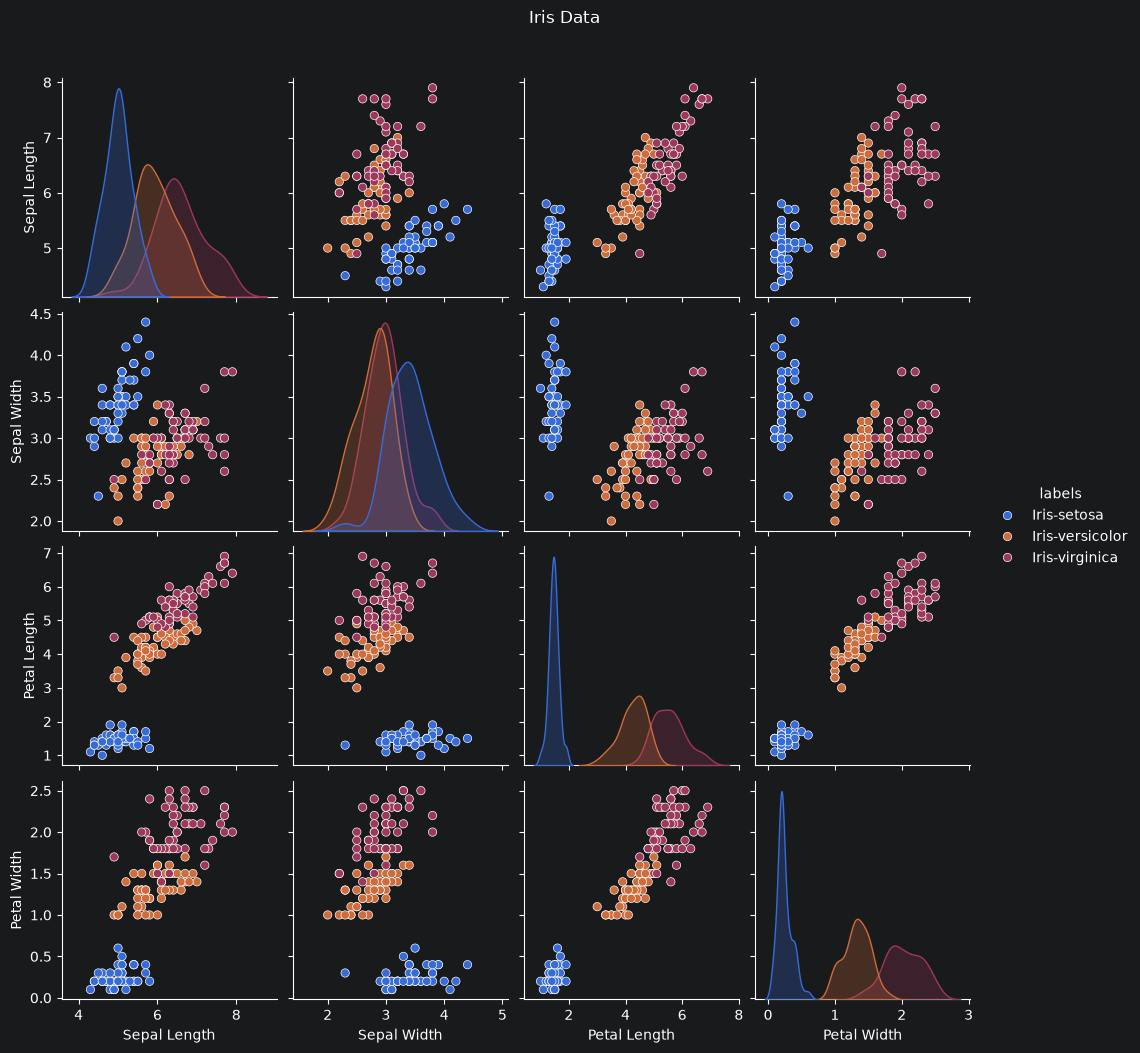

In [86]:
features = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
df = pd.DataFrame(X, columns=features)
df['labels'] = y
# citation: https://seaborn.pydata.org/generated/seaborn.pairplot.html, it gives detailed explanation of how this method works and also a example with 2 arguments used(hue and input data).
sns.pairplot(df, hue='labels')
plt.suptitle('Iris Data', y=1.05)
plt.show()

And the plot above is identical to the one in wiki(https://en.wikipedia.org/wiki/Iris_flower_data_set#/media/File:Iris_dataset_scatterplot.svg). Now let's start training the model.
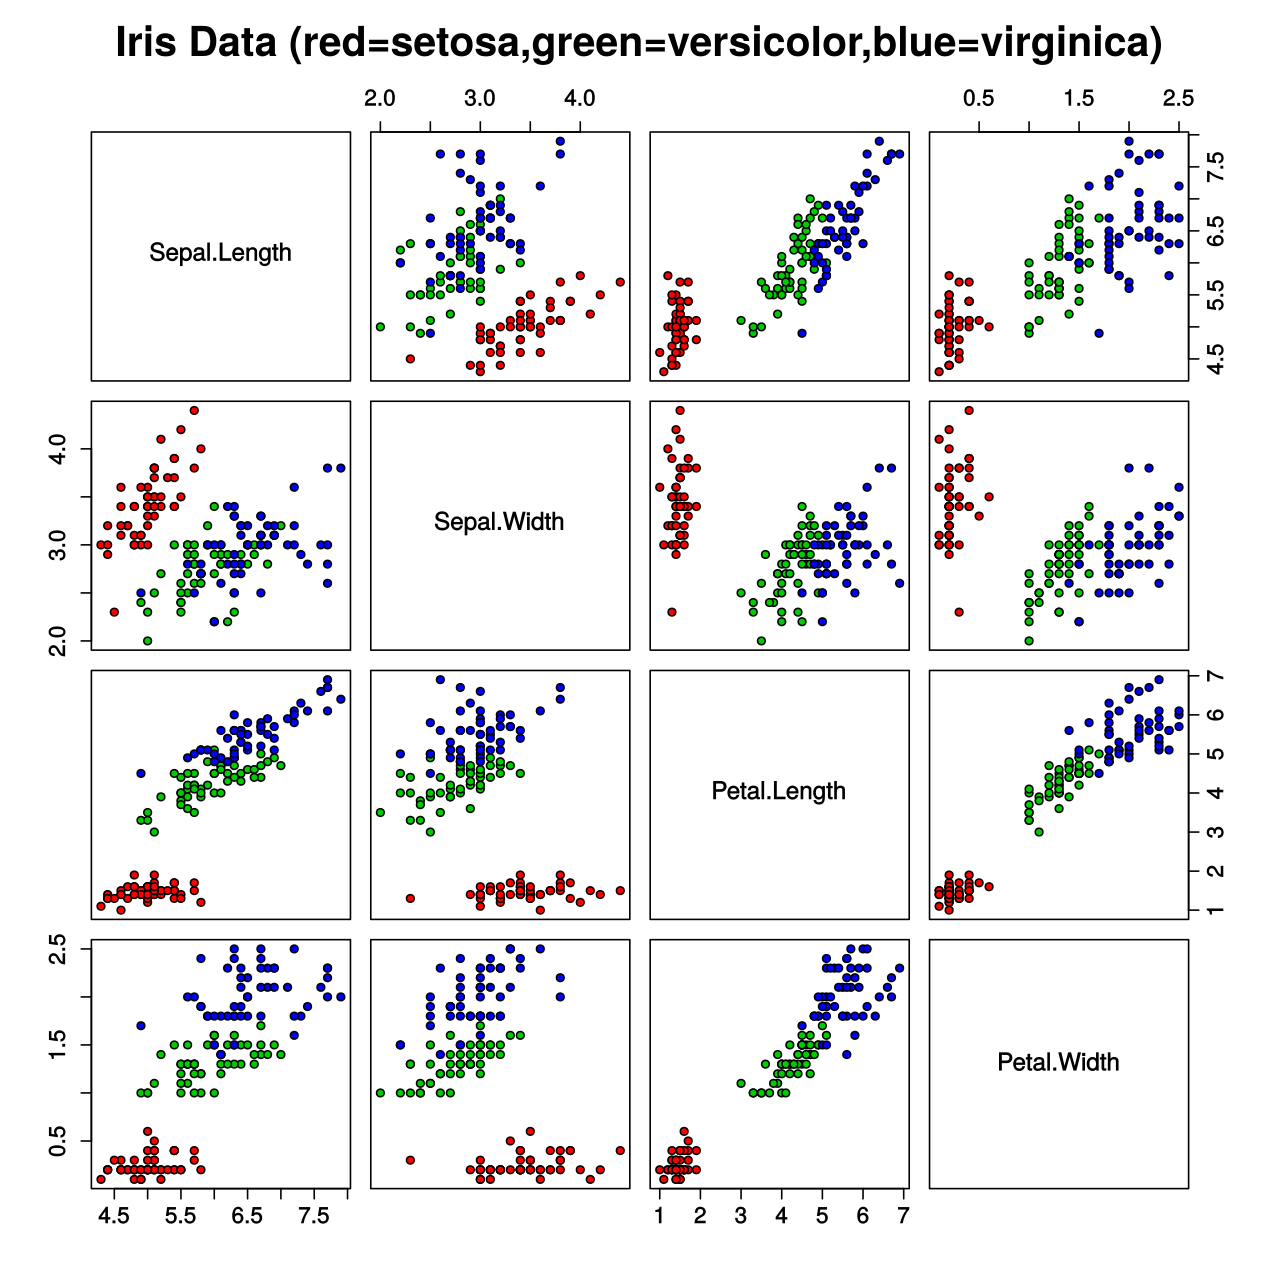

In [87]:
# citation https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html it gives example of how to set the model and how fit/score works
start = time.perf_counter()
tree = DecisionTreeClassifier(max_depth=8).fit(X_train, y_train) #train the DT model with max depth of 8
print(time.perf_counter() - start)

0.0005601659649983048


In [88]:
start = time.perf_counter()
y_pred = tree.predict(X_test)
print(time.perf_counter() - start)

0.0002079589758068323


After training, get the test and train accuracy.

In [89]:
tree.score(X_test, y_test) # test accuracy

1.0

In [90]:
tree.score(X_train, y_train) # train accuracy

1.0

Show the confusion matrix

In [91]:
#citation https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html, it gives concrete examples of cm.
confusion_matrix(y_test, y_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])